# Selección de Variables y Prototipado Rápido (AutoML)


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/10_seleccion_variables_y_automl.ipynb)

## Objetivos


- Acelerar la fase de prototipado utilizando herramientas de **AutoML** (`LazyPredict`) para establecer *baselines* de rendimiento.
- Comprender las estrategias de **Selección de Características** (Filtro, Envolvente e Integrado).
- Caso de Negocio IoT: Utilizar la Eliminación Recursiva de Características (RFE) para reducir la cantidad de sensores físicos necesarios en un dispositivo, optimizando costos de hardware y consumo de batería sin sacrificar precisión.



## Prerrequisitos


- Entendimiento de Validación Cruzada y Ensamblados.
- Haber completado: [Pipelines y Prevención de Leakage](09_pipelines_y_prevencion_leakage.ipynb).

---



## Configuración del Entorno


***Nota**: Las herramientas de Auto-EDA suelen requerir instalación adicional si no están en el entorno base.*

***En la celda de abajo, se detecta automáticamente y se intenta instalar.***

**Nota2**: En entornos locales, este tipo de *frameworks* los recomiendo instalar en un entorno virtual dedicado, así no se "rompen" otras cosas. Suelen usar muchas dependencias con versiones muy concretas...

In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

    # Instalamos lazypredict si estamos en Colab
    subprocess.run(["pip", "install", "lazypredict", "xgboost", "lightgbm"], check=True)
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

In [2]:
# Para instalar el paquete, si no se tiene
# Descomentar abajo...
# !pip install lazypredict

## Introducción Teórica



En la ingeniería tradicional, solemos pensar que "más información siempre es mejor". En Machine Learning, esto es falso. Alimentar un modelo con variables irrelevantes o redundantes genera tres problemas graves:
1. **Maldición de la Dimensionalidad:** El modelo necesita exponencialmente más datos para aprender.
2. **Sobreajuste (*Overfitting*):** El modelo puede encontrar patrones falsos en el ruido.
3. **Costo Operativo:** En sistemas físicos (IoT, medicina), cada variable extra implica comprar un sensor, consumir más batería o pagar por un examen de laboratorio adicional. Todo es dinero...

### Estrategias de Selección de Características



Para reducir la dimensionalidad, existen tres enfoques principales:
1. **Métodos de Filtrado (*Filter*):** Usan estadística pura (ej. Correlación de Pearson, ANOVA) para evaluar cada variable de forma aislada antes de entrenar cualquier modelo. Son rápidos pero ignoran las interacciones entre variables.
2. **Métodos Integrados (*Embedded*):** El algoritmo selecciona las variables *mientras* aprende. (Ej. La regularización Lasso que vimos en un *notebook* anterior, o el *Feature Importance* de los Árboles).
3. **Métodos Envolventes (*Wrapper*):** Tratan al modelo como una caja negra. Entrenan el modelo con distintas combinaciones de variables y miden el rendimiento. Son los más precisos, pero computacionalmente costosos. El estándar industrial aquí es **RFE (*Recursive Feature Elimination*)**.



## Desarrollo e Implementación



Vamos a trabajar con el **Air Quality Dataset (ADL)**. Imaginemos que somos el Ingeniero de IA en una *startup* de domótica. Diseñaron un dispositivo con **6 sensores de gas** (5 sensores MQ y 1 sensor de CO2 MG-811) para detectar si en una habitación hay alguien durmiendo, cocinando, limpiando o si hay humo.

El equipo de hardware te dice: *"Los 6 sensores cuestan $15 por unidad y agotan la batería en 2 meses. ¿Realmente necesitamos los 6?"*

### Fase 1: Prototipado Rápido con AutoML



Antes de optimizar sensores, necesitamos saber qué familia de algoritmos funciona mejor para este problema. En lugar de programar 10 modelos a mano, usamos `LazyPredict`, una herramienta de **AutoML** (*Automated Machine Learning*) que entrena varios modelos base en segundos.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier # La utilidad para "Clasificación"

# 1. Carga de datos
dataset_path = "datasets/adl/datos_adl.csv"
df = load_dataset(dataset_path)

X = df.drop(columns=['Situacion'])
y = df['Situacion']

# 2. División Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Sensores disponibles ({X.shape[1]}): {list(X.columns)}")

Dataset cargado exitosamente con 1845 filas y 7 columnas.
Sensores disponibles (6): ['MQ2', 'MQ9', 'MQ135', 'MQ137', 'MQ138', 'MG-811']


In [4]:
# 3. Ejecutamos LazyPredict (Prototipado Rápido)
# Nota: LazyPredict aplica un preprocesamiento básico (StandardScaler) automáticamente.
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None, random_state=42)
modelos_entrenados, predicciones = clf.fit(X_train, X_test, y_train, y_test)

# Mostramos el Top 5 de modelos y algunas métricas
print("\n--- Top 5 Modelos Base (AutoML) ---")
print(modelos_entrenados.head(5)[['Accuracy', 'F1 Score', 'Time Taken']])


--- Top 5 Modelos Base (AutoML) ---
                        Accuracy  F1 Score  Time Taken
Model                                                 
LabelPropagation         0.98103  0.981064    0.699745
LabelSpreading           0.97832  0.978320    1.275901
ExtraTreesClassifier     0.97290  0.972941    0.856706
KNeighborsClassifier     0.96748  0.967521    0.229616
RandomForestClassifier   0.96748  0.967560    2.009261


In [5]:
# Tabla completa:
modelos_entrenados

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
LabelPropagation,0.981030,0.975921,0.995880,0.981064,0.981411,0.981030,0.699745
LabelSpreading,0.978320,0.969511,0.995497,0.978320,0.978901,0.978320,1.275901
ExtraTreesClassifier,0.972900,0.968425,0.997183,0.972941,0.973075,0.972900,0.856706
KNeighborsClassifier,0.967480,0.964122,0.992754,0.967521,0.967785,0.967480,0.229616
RandomForestClassifier,0.967480,0.963796,0.996338,0.967560,0.967683,0.967480,2.009261
LGBMClassifier,0.962060,0.959268,0.995876,0.962114,0.962193,0.962060,1.293471
BaggingClassifier,0.945799,0.941385,0.992798,0.946039,0.946490,0.945799,0.306085
SVC,0.948509,0.939706,NaN,0.948563,0.949174,0.948509,0.324222
QuadraticDiscriminantAnalysis,0.940379,0.937713,0.988454,0.940608,0.941629,0.940379,0.212785


**Criterio de Ingeniería sobre AutoML:**

Observar los resultados. Modelos basados en árboles (ExtraTreesClassifier, Random Forest) aparecen en el Top 5 con precisiones superiores al 96%. Además, ver que aparecen otros modelos, que pueden resultar interesantes para "investigar" y determinar si son válidos para su uso en el caso.

⚠️ **Alerta:** No usar el modelo de `LazyPredict` directamente en producción. Su propósito es servir como **brújula**. Nos acaba de decir: *"Para la topología de estos datos de sensores, los ensambles de árboles son una de las mejores opciones"*. Ahora, tomamos esa información y construimos nuestro propio modelo robusto.

### Fase 2: El Caso de Negocio (RFE con Validación Cruzada)



Sabiendo que un Random Forest funciona excelente, lo usamos como "juez" para evaluar a nuestros sensores mediante **RFECV** (Eliminación Recursiva de Características con Validación Cruzada).

RFECV entrenará el modelo con los 6 sensores, eliminará el peor, validará con 5, eliminará el peor, validará con 4... y nos dirá exactamente dónde empieza a caer el rendimiento.


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Instanciamos nuestro modelo "Juez"
rf_juez = RandomForestClassifier(n_estimators=100, random_state=42)

# Configuramos RFECV
# step=1 significa que eliminaremos 1 sensor (feature) en cada iteración
selector_rfecv = RFECV(
    estimator=rf_juez,
    step=1,
    cv=StratifiedKFold(5), # 5-Fold CV para asegurar que la métrica sea real
    scoring='accuracy',
    n_jobs=-1
)

# Ejecutamos la selección
selector_rfecv.fit(X_train, y_train)

print(f"Número óptimo de sensores según la matemática pura: {selector_rfecv.n_features_}")

Número óptimo de sensores según la matemática pura: 5


### Fase 3: Análisis Costo-Beneficio



La matemática pura podría decirnos que el número óptimo es 4 o 5 sensores para alcanzar un 99,5% de precisión. Pero en ingeniería, buscamos el punto de rendimientos decrecientes (el "codo" de la curva).

Vamos a graficar cómo evoluciona la precisión a medida que agregamos sensores.

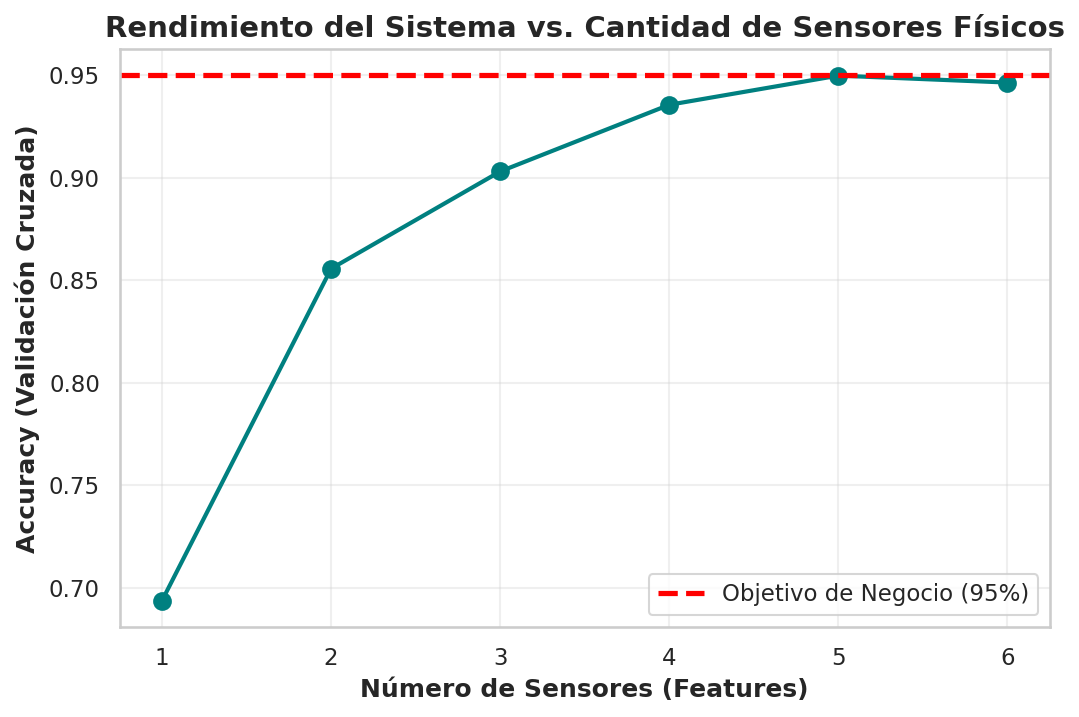


--- Ranking de Importancia de Sensores ---
   Sensor  Ranking  Seleccionado
0     MQ2        1          True
1     MQ9        1          True
2   MQ135        1          True
3   MQ137        1          True
4   MQ138        1          True
5  MG-811        2         False


In [7]:
# Extraemos los resultados de la validación cruzada
# Nota: En versiones recientes de sklearn, cv_results_ devuelve un diccionario.
resultados_cv = selector_rfecv.cv_results_['mean_test_score']
num_sensores = range(1, len(resultados_cv) + 1)

plt.figure(figsize=(8, 5))
plt.plot(num_sensores, resultados_cv, marker='o', color='teal', linewidth=2, markersize=8)

# Añadimos una línea base del 95% de precisión (nuestro objetivo de negocio)
plt.axhline(y=0.95, color='red', linestyle='--', label='Objetivo de Negocio (95%)')

plt.title("Rendimiento del Sistema vs. Cantidad de Sensores Físicos", fontsize=14)
plt.xlabel("Número de Sensores (Features)")
plt.ylabel("Accuracy (Validación Cruzada)")
plt.xticks(num_sensores)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ¿Cuáles son los sensores ganadores?
sensores_ranking = pd.DataFrame({
    'Sensor': X.columns,
    'Ranking': selector_rfecv.ranking_,
    'Seleccionado': selector_rfecv.support_
}).sort_values(by='Ranking')

print("\n--- Ranking de Importancia de Sensores ---")
print(sensores_ranking)

## Resultados y Discusión


Analizar la curva generada. Este gráfico es el que se presentaría al CEO o al Director de Hardware de la empresa... que permitiría tomar una decisión justificada. Entonces:

1. **Con 1 solo sensor:** El sistema apenas alcanza casi un $\sim 70\%$ de precisión. Es inútil (o no, habría que ver qué se pretende con el sistema, esta versión tendría ese desemperó pero **sería muy barato**).
2. **Con 2 sensores:** La precisión salta por encima del 85%.
3. **Con 6 sensores:** Alcanzamos el $\sim 94\%$.
4. **Con 5 sensores:** Alcanzamos el máximo, $\sim 95\%$. Ver que con estos resultados, probablemente un sensor extra "confunde" al modelo en algún aspecto. Por lo qué, más información, perjudica el rendimiento general. Se podría indagar sobre qué está pasando...

**La Decisión de Ingeniería:**
Pasar de 2 sensores a 6 sensores nos da un incremento marginal de $\sim 10\%$ en precisión. Sin embargo, triplica el costo del hardware (de comprar 2 sensores a comprar 6), triplica el tamaño de la placa PCB y reduce la vida útil de la batería.

Basado en este análisis, ¿cuál sería la recomendación de ingeniería?
¿Obtendríamos el mismo resultado con otro modelo? ¿Los hiperparámetros del modelo elegido influyen? El abanico se abre, es importante aplicar criterio y todo lo visto anteriormente. (¿Hay datos atípicos en algunas muestras? ¿Qué hacemos con eso?, etc. etc. etc.)



## Conclusión



Hasta este punto, recorrimos el camino de un Ingeniero de IA para problemas supervisados:
1. Empezamos entendiendo la geometría de las fronteras de decisión (Regresión Logística, SVM).
2. Comprendimos el peligro de la extrapolación y la alta varianza (Árboles).
3. Aprendimos a controlar la complejidad matemática (Regularización Ridge/Lasso).
4. Sistematizamos la búsqueda de la perfección (Grid Search, Random Forest, XGBoost).
5. Blindamos nuestros sistemas contra fugas de datos (Pipelines).
6. Y finalmente, utilizamos el Machine Learning no solo para predecir, sino para **tomar decisiones de diseño de hardware y negocio** (RFE).

Estás listo para enfrentarte a cualquier problema con datos tabulares. *La práctica hace al maestro...*, la curiosidad, investigación y pruebas con criterio... ayudan y mucho.  
Hay bibliotecas y herramientas específicas para cada etapa de un *pipeline* típico, teniendo las bases consolidadas; pueden descubrirlas e incorporarlas de a poco.

## Conexiones y Próximos Pasos


- ➡️ **Siguiente:** Aprendizaje NO Supervisado (proximamente...)



## Referencias


1. Guyon, I., Weston, J., Barnhill, S., & Vapnik, V. (2002). *Gene selection for cancer classification using support vector machines*. Machine learning, 46(1), 389-422. (Paper original de RFE).
2. [Documentación de LazyPredict](https://lazypredict.readthedocs.io/)
3. [Scikit-Learn: Recursive Feature Elimination](https://scikit-learn.org/stable/modules/feature_selection.html#recursive-feature-elimination)

---


## Entorno de Ejecución


In [8]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
lazypredict,0.3.0
lightgbm,4.6.0
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
